# Mushroom Classifier
This model's goal is to classify images of mushrooms and determine whether they are poisonous or safe.  

In [17]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
print(K.backend())

tensorflow


In [18]:
from sklearn.model_selection import train_test_split
batch_size_n = 32
img_size = (224, 224)

# Load images
dataset = keras.utils.image_dataset_from_directory(
    '../datasets/mushroom',
    batch_size=batch_size_n, 
    image_size=img_size,
    crop_to_aspect_ratio=True,
    labels='inferred',
    label_mode='categorical',
    shuffle=True,
    seed=123)

num_classes = len(dataset.class_names)

Found 6714 files belonging to 9 classes.


In [19]:
# Split dataset into validation and training
dataset_size = len(dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)

train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size).take(val_size)
test_dataset = dataset.skip(train_size + val_size)

In [20]:
# Prefetch datasets to improve performance
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
# Data augmentation to diversify content
from keras import Sequential
from keras import layers
from keras.optimizers import Adam

data_augmentation = Sequential([
    # preprocess
    layers.Rescaling(1./255),
    # augment
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

In [22]:
model = Sequential([
    layers.Input(shape=(224, 224, 3)),
    
    data_augmentation,

    # Convolution
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Output
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,121 (42.61 MB)

 Trainable params: 11,170,121 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(optimizer=Adam(learning_rate = 0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [25]:
from keras.callbacks import EarlyStopping

history = model.fit(
    train_dataset,
    batch_size=8,
    epochs=64,
    validation_data=val_dataset,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 143ms/step - accuracy: 0.3841 - loss: 1.7342 - val_accuracy: 0.4083 - val_loss: 1.6999
Epoch 2/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 18s 124ms/step - accuracy: 0.3829 - loss: 1.7162 - val_accuracy: 0.4123 - val_loss: 1.6382
Epoch 3/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 151ms/step - accuracy: 0.3948 - loss: 1.7037 - val_accuracy: 0.4456 - val_loss: 1.6262
Epoch 4/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 148ms/step - accuracy: 0.4016 - loss: 1.6728 - val_accuracy: 0.4456 - val_loss: 1.6254
Epoch 5/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - accuracy: 0.4126 - loss: 1.6487 - val_accuracy: 0.4446 - val_loss: 1.6089
Epoch 6/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 144ms/step - accuracy: 0.4167 - loss: 1.6536 - val_accuracy: 0.4345 - val_loss: 1.6427
Epoch 7/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - accuracy: 0.4386 - loss: 1.6015 - val_accuracy: 0.3962 - val_loss: 1.7092
Epoch 8/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 18s 124ms/step - accuracy: 0.4341 - loss: 1

2026-05-06 14:21:17.037594: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19269632 bytes after encountering the first element of size 19269632 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


147/147 ━━━━━━━━━━━━━━━━━━━━ 18s 124ms/step - accuracy: 0.4585 - loss: 1.5289 - val_accuracy: 0.4708 - val_loss: 1.5505
Epoch 15/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 18s 125ms/step - accuracy: 0.4683 - loss: 1.5251 - val_accuracy: 0.4435 - val_loss: 1.5931


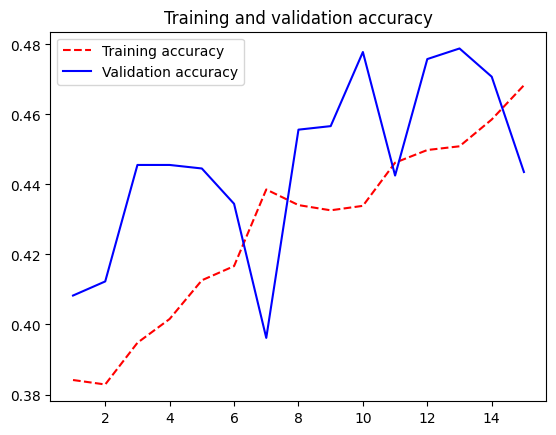

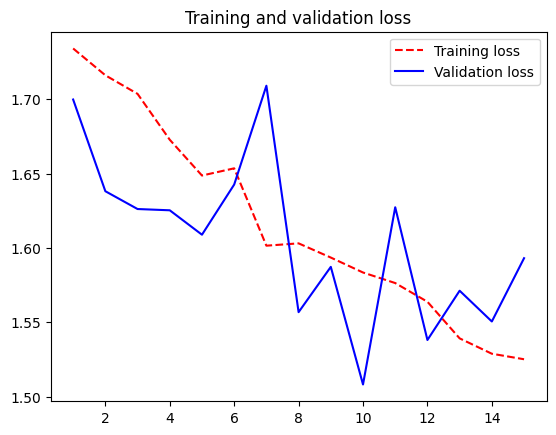

In [26]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [27]:
loss, acc = model.evaluate(test_dataset, verbose=0)
print(f"The model's test accuracy is {acc}")

The model's test accuracy is 0.450884073972702
